In [ ]:
 from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# @title Specify the path to your zipped dataset
zip_file_path = '/content/drive/MyDrive/Entry Exit Counting 2.v1i.yolov8 (1).zip' # @param {type:"string"}

# Unzip the dataset
import zipfile
import os

# Create a directory to extract the dataset into
dataset_dir = 'roboflow_dataset'
os.makedirs(dataset_dir, exist_ok=True)

# Ensure the zip file path is not empty before attempting to unzip
if zip_file_path:
    print(f"Attempting to unzip: {zip_file_path}")
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(dataset_dir)

    print(f"Dataset extracted to: {dataset_dir}")

    # List the contents of the extracted directory to verify
    print("Contents of the dataset directory:")
    !ls -F {dataset_dir}
else:
    print("Please provide the path to your zipped dataset in the 'zip_file_path' variable.")

Attempting to unzip: /content/drive/MyDrive/Entry Exit Counting 2.v1i.yolov8 (1).zip
Dataset extracted to: roboflow_dataset
Contents of the dataset directory:
data.yaml  README.dataset.txt  README.roboflow.txt  test/  train/  valid/


In [ ]:
pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.8 MB/s eta 0:00:00


Now that the `ultralytics` library is installed, let's load the `data.yaml` file to see the dataset configuration, such as class names and image paths.

In [ ]:
import yaml

data_yaml_path = os.path.join(dataset_dir, 'data.yaml')

with open(data_yaml_path, 'r') as file:
    data_config = yaml.safe_load(file)

print("Dataset Configuration (data.yaml):")
print(data_config)

Dataset Configuration (data.yaml):
{'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 2, 'names': ['human-walk-in', 'human-walk-out'], 'roboflow': {'workspace': 'shreyashs-workspace-zijct', 'project': 'entry-exit-counting-2', 'version': 1, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/shreyashs-workspace-zijct/entry-exit-counting-2/dataset/1'}}


With the dataset configured, we can now initialize and train a YOLOv8 model. We'll use a pre-trained `yolov8n.pt` model, which is a good balance of speed and accuracy, and fine-tune it with our custom dataset.

In [ ]:
from ultralytics import YOLO

# Load a pre-trained YOLOv8n model
model = YOLO('yolov8n.pt')  # You can choose other models like 'yolov8s.pt', 'yolov8m.pt', etc.

# Train the model
# The 'data' argument points to our data.yaml configuration file
# 'epochs' can be adjusted based on dataset size and desired accuracy
# 'imgsz' defines the image size for training
results = model.train(data=data_yaml_path, epochs=50, imgsz=640)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.50 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=roboflow_dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgs

After the model training is complete, we can access the performance metrics. While 'accuracy' isn't a direct metric for object detection in the same way it is for classification, we can look at precision, recall, and mAP (mean Average Precision).

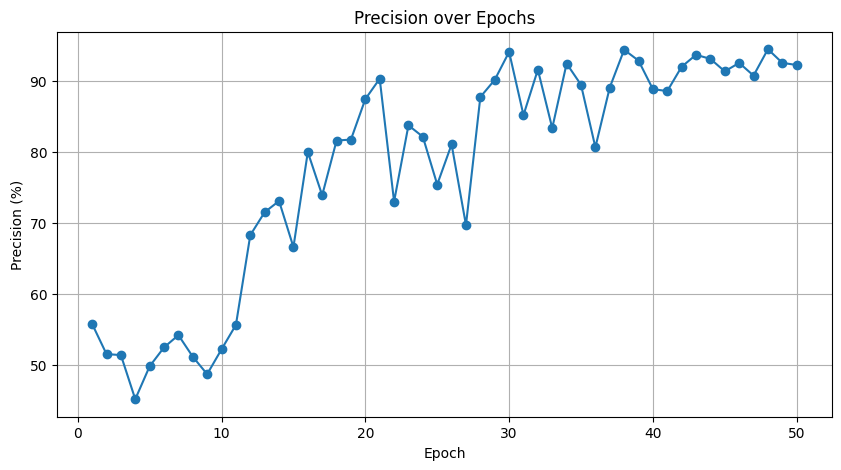

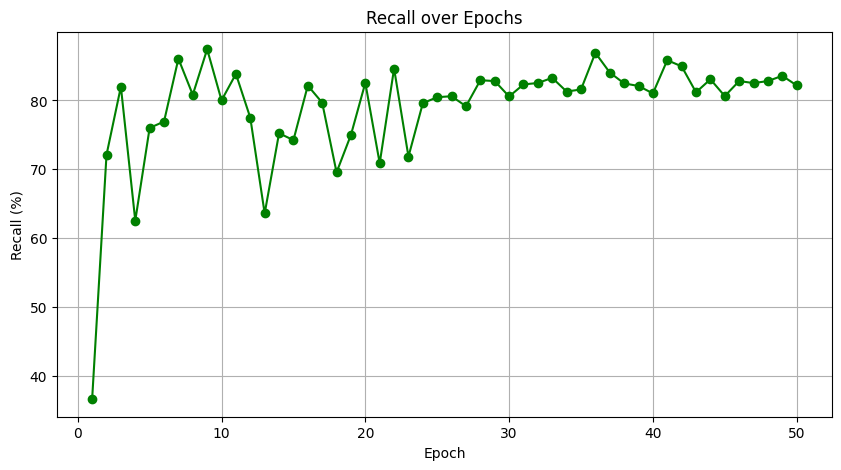

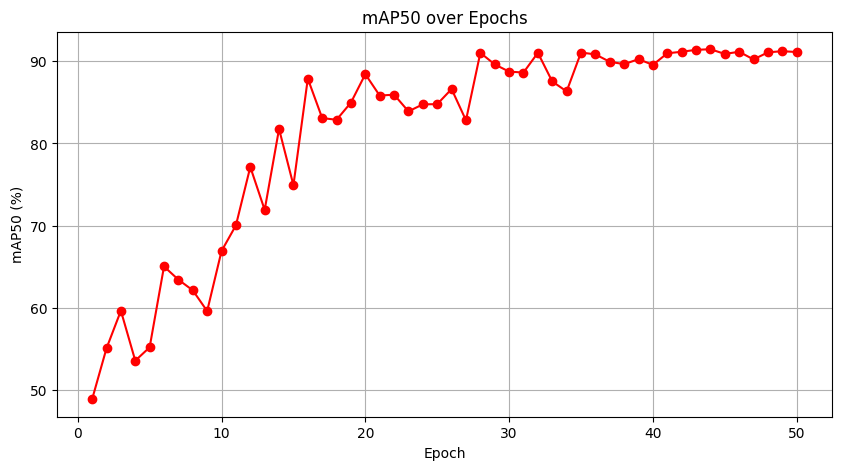

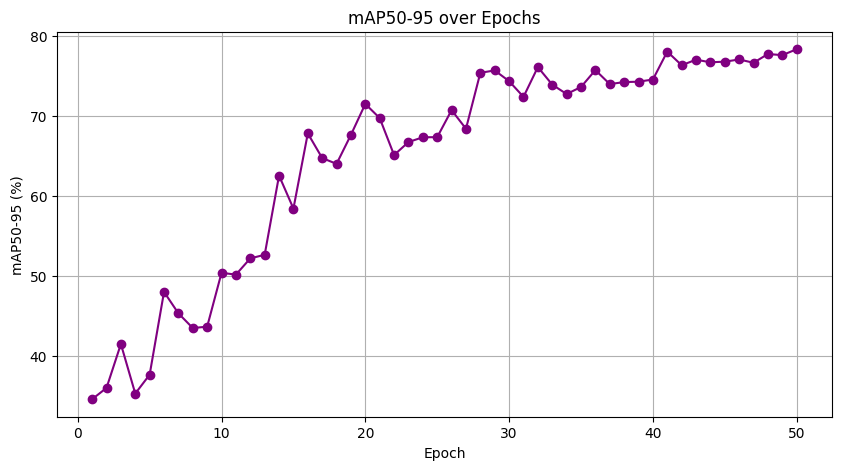

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import os

# Define the path to the training run directory
run_dir = '/content/runs/detect/train'
results_csv_path = os.path.join(run_dir, 'results.csv')

if os.path.exists(results_csv_path):
    df_metrics = pd.read_csv(results_csv_path, comment='#')
    epochs = df_metrics['epoch']

    # Plot Precision
    plt.figure(figsize=(10, 5))
    plt.plot(epochs, df_metrics['metrics/precision(B)'] * 100, marker='o')
    plt.title('Precision over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Precision (%)')
    plt.grid(True)
    plt.show()

    # Plot Recall
    plt.figure(figsize=(10, 5))
    plt.plot(epochs, df_metrics['metrics/recall(B)'] * 100, marker='o', color='green')
    plt.title('Recall over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Recall (%)')
    plt.grid(True)
    plt.show()

    # Plot mAP50
    plt.figure(figsize=(10, 5))
    plt.plot(epochs, df_metrics['metrics/mAP50(B)'] * 100, marker='o', color='red')
    plt.title('mAP50 over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('mAP50 (%)')
    plt.grid(True)
    plt.show()

    # Plot mAP50-95
    plt.figure(figsize=(10, 5))
    plt.plot(epochs, df_metrics['metrics/mAP50-95(B)'] * 100, marker='o', color='purple')
    plt.title('mAP50-95 over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('mAP50-95 (%)')
    plt.grid(True)
    plt.show()

else:
    print(f"Could not find results.csv at {results_csv_path}. Cannot generate plots.")

In [ ]:
import pandas as pd
import os

# Define the path to the training run directory
# This path is where Ultralytics saves the training results, including results.csv
run_dir = '/content/runs/detect/train'

# Path to the results.csv file
results_csv_path = os.path.join(run_dir, 'results.csv')

if os.path.exists(results_csv_path):
    # Read the CSV file, skipping comment lines that start with '#'
    df = pd.read_csv(results_csv_path, comment='#')

    # The last row of the DataFrame contains the final validation metrics
    last_epoch_metrics = df.iloc[-1]

    print("\n--- Model Performance Metrics (from results.csv) ---")
    print(f"Precision (P): {last_epoch_metrics.get('metrics/precision(B)', 'N/A') * 100:.2f}%")
    print(f"Recall (R): {last_epoch_metrics.get('metrics/recall(B)', 'N/A') * 100:.2f}%")
    print(f"mAP50: {last_epoch_metrics.get('metrics/mAP50(B)', 'N/A') * 100:.2f}%")
    print(f"mAP50-95: {last_epoch_metrics.get('metrics/mAP50-95(B)', 'N/A') * 100:.2f}%")
else:
    print(f"Could not find results.csv at {results_csv_path}. Please ensure training completed successfully and check the run directory.")


--- Model Performance Metrics (from results.csv) ---
Precision (P): 92.30%
Recall (R): 82.18%
mAP50: 91.11%
mAP50-95: 78.30%


In [ ]:
import os

# List the contents of the runs/detect directory to find the actual training run folder
print("Contents of /content/runs/detect/")
!ls -R /content/runs/detect/

Contents of /content/runs/detect/
/content/runs/detect/:
train

/content/runs/detect/train:
args.yaml			 labels.jpg	      train_batch2762.jpg
BoxF1_curve.png			 results.csv	      train_batch2.jpg
BoxP_curve.png			 results.png	      val_batch0_labels.jpg
BoxPR_curve.png			 train_batch0.jpg     val_batch0_pred.jpg
BoxR_curve.png			 train_batch1.jpg     val_batch1_labels.jpg
confusion_matrix_normalized.png  train_batch2760.jpg  val_batch1_pred.jpg
confusion_matrix.png		 train_batch2761.jpg  weights

/content/runs/detect/train/weights:
best.pt  last.pt


After training, the `results` object contains information about the training process and the trained model will be saved in a `runs` directory.

Now that we have trained the model, let's load the best-performing weights and use them to make predictions on a sample image from the test set.

In [ ]:
from ultralytics import YOLO
import os
from IPython.display import Image, display

# Load the best trained model weights
# The 'best.pt' file is saved in the 'runs/detect/train' directory by default after training
model_path = '/content/runs/detect/train/weights/best.pt'
model = YOLO(model_path)

print(f"Model loaded from: {model_path}")

Model loaded from: /content/runs/detect/train/weights/best.pt


Let's pick a sample image from the `test` set to see the model in action.

Using sample image for inference: roboflow_dataset/test/images/uppic_10157_jpg.rf.021adbb41411c0b67814b76a89ca30fd.jpg

image 1/1 /content/roboflow_dataset/test/images/uppic_10157_jpg.rf.021adbb41411c0b67814b76a89ca30fd.jpg: 640x640 1 human-walk-out, 7.3ms
Speed: 2.0ms preprocess, 7.3ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)


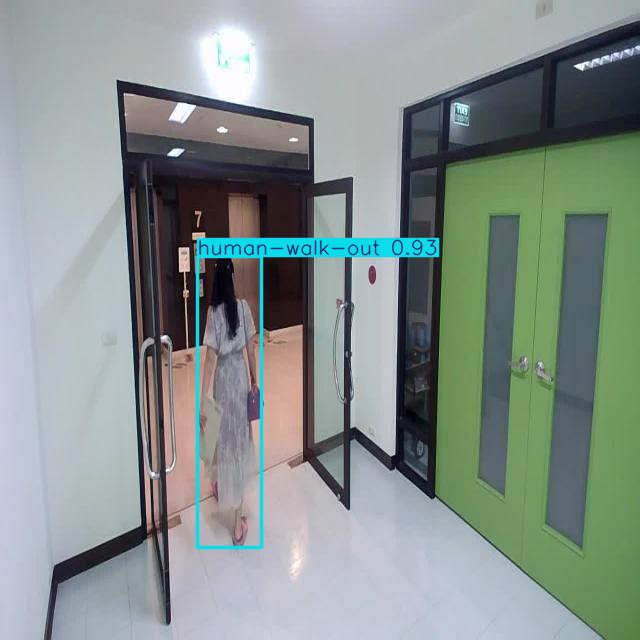

In [ ]:
from ultralytics import YOLO
import os
from IPython.display import Image, display
from PIL import Image as PImage # Import PIL Image and alias it to PImage to avoid name collision

# Get the path to the test images
# The paths in data.yaml like '../test/images' are relative to the parent directory of where data.yaml is typically expected.
# Since we extracted everything into 'roboflow_dataset', we need to adjust these paths.
# We strip the leading '../' and then join with dataset_dir.
test_images_relative_path = data_config['test'].replace('../', '', 1)
test_images_path = os.path.join(dataset_dir, test_images_relative_path)

# List all image files in the test directory
image_files = [os.path.join(test_images_path, f) for f in os.listdir(test_images_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))]

if image_files:
    sample_image_path = image_files[0] # Pick the first image
    print(f"Using sample image for inference: {sample_image_path}")

    # Perform inference
    results = model(sample_image_path)

    # Display the results
    # The 'results' object contains predictions, and it can save the annotated image
    for r in results:
        im_array = r.plot()  # plot a BGR numpy array of predictions
        im = PImage.fromarray(im_array[..., ::-1])  # RGB PIL image - using PImage
        display(im)

        # Optionally, save the annotated image
        # annotated_image_path = os.path.join(dataset_dir, 'predicted_image.jpg')
        # im.save(annotated_image_path)
        # print(f"Annotated image saved to: {annotated_image_path}")

else:
    print(f"No image files found in {test_images_path}")

Using sample validation image for inference: roboflow_dataset/valid/images/uppic_3547_jpg.rf.68c2ca99968b2e7add10450bba127d12.jpg

image 1/1 /content/roboflow_dataset/valid/images/uppic_3547_jpg.rf.68c2ca99968b2e7add10450bba127d12.jpg: 640x640 1 human-walk-in, 8.5ms
Speed: 2.1ms preprocess, 8.5ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)


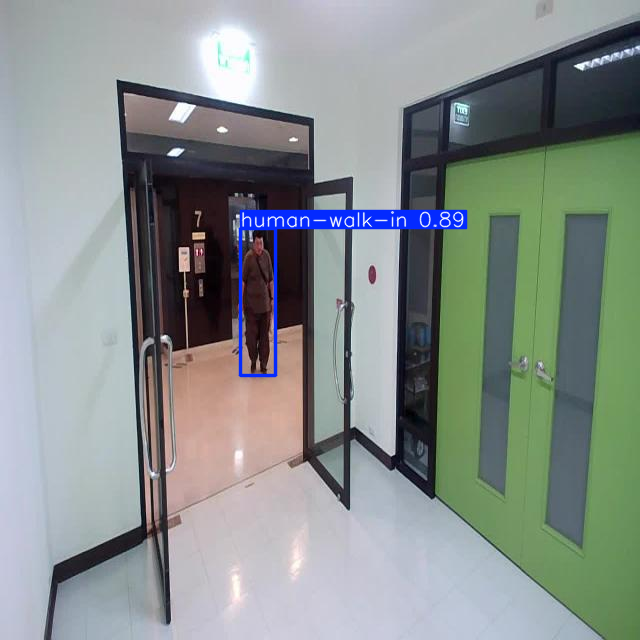

In [ ]:
import random
from ultralytics import YOLO
import os
from IPython.display import Image, display
from PIL import Image as PImage # Import PIL Image and alias it to PImage to avoid name collision

# Load the best trained model weights if not already loaded (e.g., if this cell is run independently)
if 'model' not in locals():
    model_path = '/content/runs/detect/train/weights/best.pt'
    model = YOLO(model_path)
    print(f"Model loaded from: {model_path}")

# Get the path to the validation images
# The paths in data.yaml like '../valid/images' are relative to the parent directory of where data.yaml is typically expected.
# Since we extracted everything into 'roboflow_dataset', we need to adjust these paths.
# We strip the leading '../' and then join with dataset_dir.
val_images_relative_path = data_config['val'].replace('../', '', 1)
val_images_path = os.path.join(dataset_dir, val_images_relative_path)

# List all image files in the validation directory
val_image_files = [os.path.join(val_images_path, f) for f in os.listdir(val_images_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))]

if val_image_files:
    sample_val_image_path = random.choice(val_image_files) # Pick a random image from the validation set
    print(f"Using sample validation image for inference: {sample_val_image_path}")

    # Perform inference
    results = model(sample_val_image_path)

    # Display the results
    for r in results:
        im_array = r.plot()  # plot a BGR numpy array of predictions
        im = PImage.fromarray(im_array[..., ::-1])  # RGB PIL image - using PImage
        display(im)
else:
    print(f"No image files found in {val_images_path}")